# Guven 数据实际电极分布

直接用预处理后 epoch 文件（`fft/guven/preprocess.py` 产出，montage 已经通过 `standard_1020` 对齐）里保存的定位信息画头模型图，不额外读取任何 `.elc`/坐标文件。

In [1]:
import mne

EPOCH_FILE = "/home/dilay/project2/tw/Data/guven_data/epoch_threshold/sub01_session1.fif"

epochs = mne.read_epochs(EPOCH_FILE, preload=False, verbose=False)
picks = mne.pick_types(epochs.info, eeg=True, eog=False)
info = mne.pick_info(epochs.info, picks)
print(f"{len(info['ch_names'])} EEG channels")
info.get_montage()

64 EEG channels


/tmp/ipykernel_3843602/2856590843.py:5: RuntimeWarning: This filename (/home/dilay/project2/tw/Data/guven_data/epoch_threshold/sub01_session1.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(EPOCH_FILE, preload=False, verbose=False)


<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 64 channels>

## 2D 头模型图（鼻子+耳朵轮廓）

`mne.viz.plot_sensors(kind="topomap")` 内部用的投影会让前额（Fpz 等）几乎贴着圆周边界、而枕部（Iz/Oz）挤在圆心附近，两侧看起来明显不对称——这是 MNE 内置 `standard_1020` 模板本身在那个投影方式下的固有几何特性（用纯 MNE 自带模板、不涉及 guven 任何数据也复现同样的不对称），不是数据错误，但不利于手动挑电极线。

这里换成手动实现的方位角等距投影（以 Cz 为极点，用到每个通道相对 Cz 的真实球面夹角作为半径，鼻侧方向为方位角 0°），这是经典 EEG 拓扑图（比如 EEGLAB 的 topoplot）通用的做法，前后会对称、成比例，CP1/CP2 缺口这种真实特征仍然如实保留。

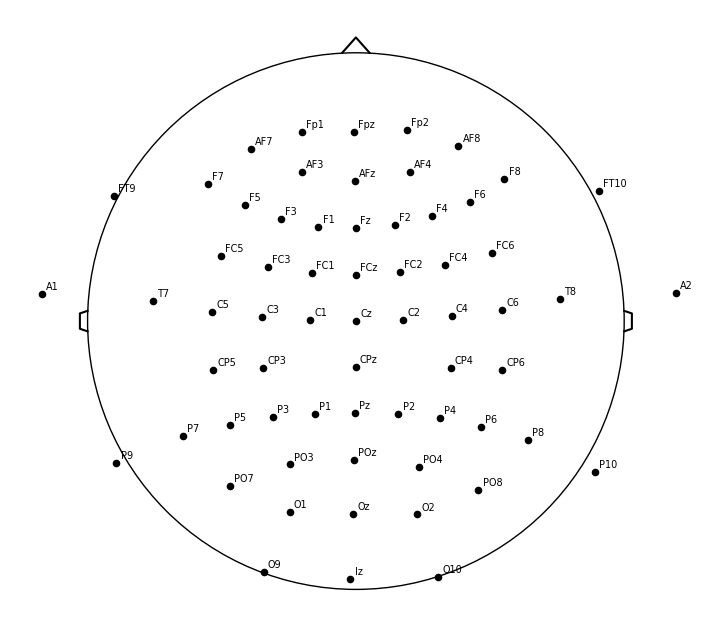

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def azimuthal_equidistant_projection(ch_pos: dict[str, np.ndarray], nasion: np.ndarray, vertex_ch: str = "Cz"):
    """Project 3D electrode positions to 2D using Cz as the pole: radius is the
    true spherical angle from Cz (so front/back stay proportional to their real
    arc distance), angle is azimuth around Cz with the nasion direction as 0deg.
    """
    names = list(ch_pos.keys())
    xyz = np.array([ch_pos[n] for n in names])
    center = np.zeros(3)  # fiducials are symmetric around the origin in the "head" frame

    vertex_dir = ch_pos[vertex_ch] - center
    vertex_dir /= np.linalg.norm(vertex_dir)

    front = nasion - center
    front = front - np.dot(front, vertex_dir) * vertex_dir
    front /= np.linalg.norm(front)
    right = np.cross(front, vertex_dir)
    right /= np.linalg.norm(right)

    v = xyz - center
    elev = np.arccos(np.clip(v @ vertex_dir / np.linalg.norm(v, axis=1), -1, 1))
    u = v @ right
    w = v @ front
    theta = np.arctan2(u, w)
    xy = np.column_stack([elev * np.sin(theta), elev * np.cos(theta)])
    return dict(zip(names, xy))


def plot_head_model(xy: dict[str, np.ndarray], head_r: float = np.pi / 2, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 9))
    ax.add_patch(plt.Circle((0, 0), head_r, fill=False, color="k"))
    ax.plot([-0.08, 0, 0.08], [head_r, head_r + 0.09, head_r], "k-")  # nose
    for side in (-1, 1):
        ax.plot(
            [side * head_r, side * (head_r + 0.045), side * (head_r + 0.045), side * head_r],
            [0.06, 0.045, -0.045, -0.06],
            "k-",
        )  # ears
    pts = np.array(list(xy.values()))
    ax.scatter(pts[:, 0], pts[:, 1], s=20, c="k")
    for name, (x, y) in xy.items():
        ax.annotate(name, (x, y), fontsize=7, xytext=(3, 3), textcoords="offset points")
    ax.set_aspect("equal")
    ax.axis("off")
    return ax


montage = info.get_montage()
montage_pos = montage.get_positions()
xy_2d = azimuthal_equidistant_projection(montage_pos["ch_pos"], montage_pos["nasion"])
plot_head_model(xy_2d)
plt.show()

## 3D 散点图（真实 xyz 坐标）

这里是 `info`（来自 epoch 文件的 montage）里每个通道的真实 3D 坐标，不是投影后的 2D 位置。

注：环境里没装 `pyvistaqt`，没法渲染带贴图的头皮球面模型，只能是散点图；如果需要真正的 3D 头皮渲染，需要 `pip install pyvistaqt` 才能用 `mne.viz.plot_alignment`。

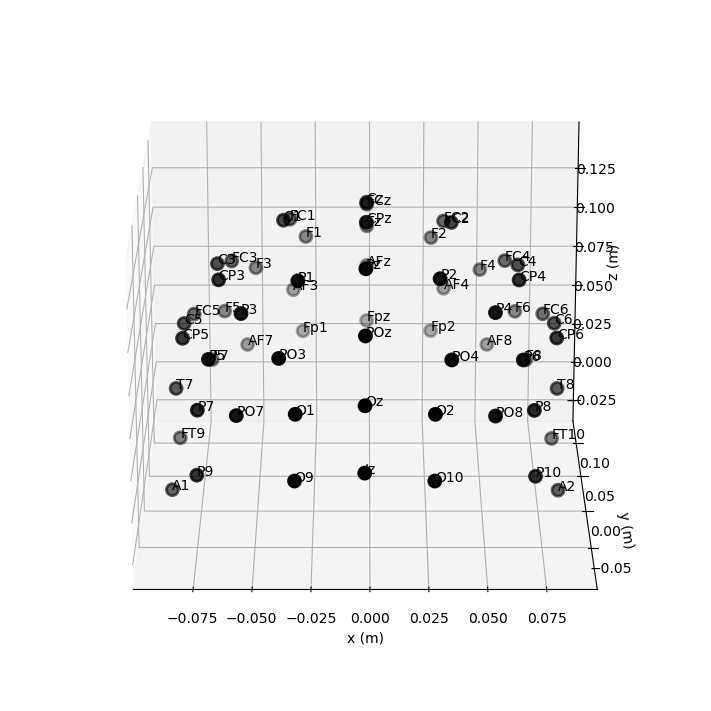

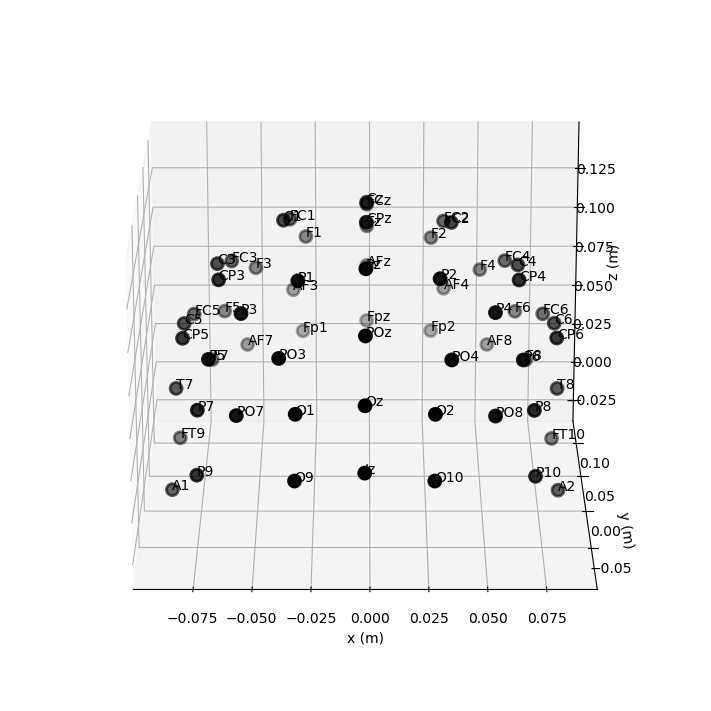

In [3]:
fig_3d = mne.viz.plot_sensors(info, kind="3d", show_names=True, show=False)
fig_3d.axes[0].view_init(elev=20, azim=-90)
fig_3d.set_size_inches(7, 7)
fig_3d